In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import numpy as np
import warnings
warnings.filterwarnings("ignore")
# 设置样式（避免中文乱码）
plt.rcParams['font.family'] = ['DejaVu Sans', 'Arial', 'sans-serif']
sns.set_style("whitegrid")

### 定义操作码的类别，定义规则如下：
1. 类别	操作码	解释说明
2. Data Operation Codes	PUSH1-PUSH32, DUP1-DUP16, SWAP1-SWAP16, MSTORE, MLOAD, SSTORE, SLOAD	这些操作码主要涉及对数据的处理、存储和访问。
3. Arithmetic Operation Codes	ADD, MUL, SUB, DIV, MOD	这些操作码用于执行数学运算，如加法、减法、乘法、除法等。
4. Logical Operation Codes	AND, OR, XOR, NOT	这些操作码用于执行布尔运算。
5. Control Flow Operation Codes	JUMP, JUMPI, JUMPDEST, STOP, REVERT	这些操作码用于控制程序的流向，涉及跳转、条件分支和停止执行。
6. Contract Interaction Operation Codes	CALL, CALLCODE, DELEGATECALL, STATICCALL, CREATE, CREATE2, SELFDESTRUCT	这些操作码用于与其他智能合约交互或调用合约内的函数。
7. Block Operation Codes	B LOCKHASH, COINBASE, TIMESTAMP, NUMBER, DIFFICULTY, GASLIMIT	这些操作码涉及区块链层面的操作。
8. Preprocessing Operation Codes	CALLDATALOAD, CALLDATASIZE, CALLDATACOPY, RETURNDATACOPY, RETURNDATASIZE, GAS	这些操作码用于与输入数据进行交互。
9. Hash Operation Codes	SHA3, KECCAK256	这些操作码用于计算哈希值。
10. Auxiliary Operation Codes	LOG0-LOG4, PC, MSIZE, SIZETOKEN	这些操作码通常用于辅助计算或调试。
11. Other Codes		不属于上述的其他类别


In [139]:
##  问题我们对于每个操作如何提取它的节点特征作为超图中的节点特征
# 1. 统计每个操作码在所有合约中的出现频率
# 2. 使用TF-IDF对操作码进行向量化表示
# 3. 使用预训练的词向量模型（如Word2Vec或GloVe）来获取操作码的嵌入表示
# 4. 使用one-hot编码表示操作码
# 5. 使用操作码的上下文信息，通过语言模型（如BERT）来获取操作码的嵌入表示

#当前合约操作码总数 ≈ 140 余条
# 设计操作码类别和操作码列表
opcode_categories = {
    #堆栈操作——1
    "Stack Operations": [
        "DUP1", "DUP2", "DUP3", "DUP4", "DUP5", "DUP6", "DUP7", "DUP8", 
        "DUP9", "DUP10", "DUP11", "DUP12", "DUP13", "DUP14", "DUP15", "DUP16", "POP",
        "PUSH1", "PUSH2", "PUSH3", "PUSH4", "PUSH5", "PUSH6", "PUSH7", "PUSH8", 
        "PUSH9", "PUSH10", "PUSH11", "PUSH12", "PUSH13", "PUSH14", "PUSH15", "PUSH16", 
        "PUSH17", "PUSH18", "PUSH19", "PUSH20", "PUSH21", "PUSH22", "PUSH23", "PUSH24", 
        "PUSH25", "PUSH26", "PUSH27", "PUSH28", "PUSH29", "PUSH30", "PUSH31", "PUSH32",
        "SWAP1", "SWAP2", "SWAP3", "SWAP4", "SWAP5", "SWAP6", "SWAP7", "SWAP8", 
        "SWAP9", "SWAP10", "SWAP11", "SWAP12", "SWAP13", "SWAP14", "SWAP15", "SWAP16",
    ],
    #存储操作——2
    "Storage Operations":[
        "SSTORE", "SLOAD", "MSTORE", "MLOAD", "MSTORE8", "MLOAD8", "PULL"
    ],
    #算数与逻辑操作——3
    "Mathematics and Logical Operations":[
        'AND', 'MUL', 'SUB', 'DIV', 'MOD','EXP','SIGNEXTEND','LT','GT','EQ','OR','XOR','NOT','ADD'
    ],
    #合约创建和销毁操作——4
    "Contract Creation and Destruction Operations": [
        "CREATE", "CREATE2", "SELFDESTRUCT"
    ],

    #合约调用和消息传递操作——5
    "Contract Call Operations": [
        "CALL", "CALLCODE", "DELEGATECALL", "STATICCALL", "RETURN", "REVERT", "INVALID", "STATICCALL"
    ],
    #跳转和分支 操作——6
    "Control Flow and Branching Operations": [
        "JUMP", "JUMPI", "JUMPDEST","PC", "MSIZE", "GAS"
    ],  
    #日志操作   ——7
    "Events and Logs Operations": [
        "LOG0", "LOG1", "LOG2", "LOG3", "LOG4"
    ],
    #时间和区块信息操作 ——8
    "Time and Block Information Operations": [
        "TIMESTAMP", "NUMBER", "DIFFICULTY", "GASLIMIT", "COINBASE", "BLOCKHASH"
    ],
    #环境信息操作 ——9
    "Environmental Information Operations": [
        "ADDRESS", "BALANCE", "ORIGIN", "CALLER", "CALLVALUE", "CODESIZE", "CODECOPY", "EXTCODESIZE", "EXTCODECOPY"
    ],
    #  异常处理  ——10
    "Error Handling Operations": [
        "REVERT", "INVALID"
    ]
}

In [140]:
# 1. 柱状图
def plot_opcode_category_bar(categories, counts, percentages):
    colors = plt.cm.Set3(np.linspace(0, 1, len(categories)))
    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.bar(range(len(categories)), counts, color=colors, alpha=0.7)
    ax.set_title('Opcode Count by Category', fontweight='bold')
    ax.set_xlabel('Opcode Categories')
    ax.set_ylabel('Count')
    ax.set_xticks(range(len(categories)))
    ax.set_xticklabels(categories, rotation=45, ha='right')
    for i, bar in enumerate(bars):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                f'{counts[i]} {percentages[i]}', ha='center', va='bottom', fontweight='bold')
    plt.tight_layout()
    plt.show()

# 主函数
def classify_and_visualize_opcodes(opcode_sequence, opcode_categories):
    # 初始化分类结果
    categorized = {category: [] for category in opcode_categories.keys()}
    categorized['Other'] = []

    opcodes = opcode_sequence.split()
    total_opcodes = len(opcodes)

    for op in opcodes:
        found = False
        for category, op_list in opcode_categories.items():
            if op in op_list:
                categorized[category].append(op)
                found = True
                break
        if not found:
            categorized['Other'].append(op)

    categories = []
    counts = []
    percentages = []
    for category, ops in categorized.items():
        if ops:
            count = len(ops)
            categories.append(category)
            counts.append(count)
            percentages.append(f'({count/total_opcodes*100:.1f}%)')

    opcode_freq = Counter(opcodes)

    # 绘图（分开执行）
    # plot_opcode_category_bar(categories, counts, percentages)

    # # 控制台输出
    # print("=" * 60)
    # print("EVM OPCODE ANALYSIS RESULTS")
    # print("=" * 60)
    # print(f"Total opcodes: {total_opcodes}")
    # print(f"Unique opcode types: {len(opcode_freq)}")
    # print(f"Most frequent opcode: {opcode_freq.most_common(1)[0][0]} ({opcode_freq.most_common(1)[0][1]} times)")
    # print("\nCategory Breakdown:")
    # for i, category in enumerate(categories):
    #     print(f"  {category}: {counts[i]} opcodes {percentages[i]}")
    # print("\nTop 10 Most Frequent Opcodes:")
    # for i, (op, count) in enumerate(opcode_freq.most_common(10), 1):
    #     print(f"  {i:2d}. {op:12} : {count:3d} times")

    return categorized, opcode_freq

In [141]:
import pandas as pd 
ponzi_concat = pd.read_csv('./data/2PonziContract_20220701.csv')

In [142]:
ponzi_concat.columns

Index(['address', 'opcode', 'code', 'contractCode', 'createValue',
       'createdBlockNumber', 'createdTransactionHash', 'creationCode',
       'creator', 'label', 'timestamp'],
      dtype='object')

In [143]:
import random
# 随机选择一个标签为1的opcode序列进行分析
ponzi_concat_opcode_sequence = random.choice(ponzi_concat[ponzi_concat['label'] == 1]['opcode'].values)
concat_opcode_sequence = random.choice(ponzi_concat[ponzi_concat['label'] == 0]['opcode'].values)

In [144]:
categorized1, opcode_freq1 = classify_and_visualize_opcodes(ponzi_concat_opcode_sequence, opcode_categories)

In [145]:
categorized0, opcode_freq0 = classify_and_visualize_opcodes(concat_opcode_sequence, opcode_categories)

In [146]:
import itertools
import numpy as np

def cooccur_matrix(opcodes, window=10):
    """简单滑窗共现矩阵（opcode层面）"""
    vocab = sorted(set(opcodes))
    idx = {op:i for i,op in enumerate(vocab)}
    M = np.zeros((len(vocab), len(vocab)), dtype=np.float64)
    for i in range(len(opcodes)):
        for j in range(i+1, min(i+window, len(opcodes))):
            a, b = idx[opcodes[i]], idx[opcodes[j]]
            M[a,b] += 1; M[b,a] += 1
    return vocab, M

def avg_pmi_intra_inter(vocab, M, opcode_categories):
    """粗略PMI：pmi(i,j)=log( (co/pairs) / (pi*pj) )，用于比较类内/类间平均"""
    total_co = M.sum()
    if total_co == 0: return 0,0
    pi = M.sum(axis=1) / total_co
    pmi = np.zeros_like(M)
    for i in range(len(vocab)):
        for j in range(len(vocab)):
            if M[i,j] > 0 and pi[i]>0 and pi[j]>0:
                pmi[i,j] = np.log((M[i,j]/total_co) / (pi[i]*pi[j]) + 1e-12)

    # 映射 opcode -> 类
    op2cat = {}
    for cat, ops in opcode_categories.items():
        for op in ops:
            op2cat[op] = cat

    intra_vals, inter_vals = [], []
    for i,j in itertools.combinations(range(len(vocab)), 2):
        ci, cj = op2cat.get(vocab[i],'Other'), op2cat.get(vocab[j],'Other')
        if ci == cj:
            intra_vals.append(pmi[i,j])
        else:
            inter_vals.append(pmi[i,j])

    return (np.mean(intra_vals) if intra_vals else 0.0,
            np.mean(inter_vals) if inter_vals else 0.0)


In [147]:
vocab, M = cooccur_matrix(concat_opcode_sequence)

In [148]:
x = avg_pmi_intra_inter(vocab, M, opcode_categories)

In [149]:
import math

def entropy_of_categories(categories, counts):
    total = sum(counts)
    if total == 0: return 0.0
    ps = [c/total for c in counts]
    return -sum(p*math.log(p+1e-12) for p in ps)

def gini_of_categories(categories, counts):
    total = sum(counts)
    if total == 0: return 0.0
    ps = [c/total for c in counts]
    return 1 - sum(p*p for p in ps)
entropy1 = entropy_of_categories(list(categorized1.keys()), [len(v) for v in categorized1.values()])
gini1 = gini_of_categories(list(categorized1.keys()), [len(v) for v in categorized1.values()]) 
print(f"Ponzi Contract Entropy: {entropy1:.4f}, Gini: {gini1:.4f}")

Ponzi Contract Entropy: 1.3602, Gini: 0.6223


In [150]:
entropy0 = entropy_of_categories(list(categorized0.keys()), [len(v) for v in categorized0.values()])
gini0 = gini_of_categories(list(categorized0.keys()), [len(v) for v in categorized0.values()])
print(f"normal Contract Entropy: {entropy0:.4f}, Gini: {gini0:.4f}")

normal Contract Entropy: 1.3342, Gini: 0.6196


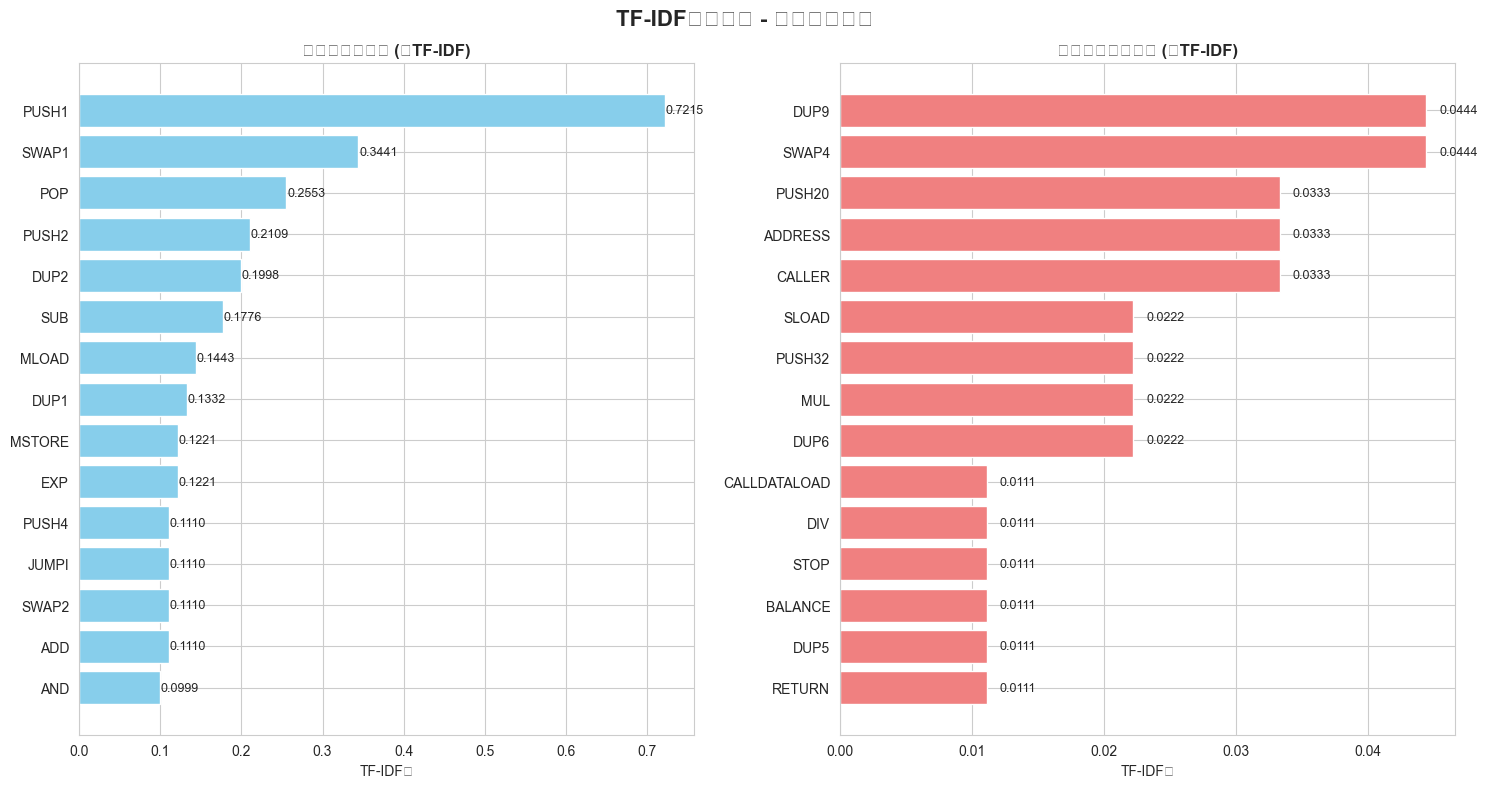

In [151]:
import numpy as np
from sklearn.feature_extraction.text import TfidfTransformer
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

# 设置样式
plt.rcParams['font.family'] = ['DejaVu Sans', 'Arial', 'sans-serif']
sns.set_style("whitegrid")

def tfidf_opcode_features(opcode_sequence):
    """
    使用TF-IDF为操作码序列中的每个操作码提取特征
    
    参数:
    opcode_sequence: 操作码字符串序列
    
    返回:
    opcode_features: 字典，键为操作码，值为TF-IDF特征向量
    tfidf_matrix: 完整的TF-IDF矩阵
    """
    
    # 分割操作码序列
    opcodes = opcode_sequence.split()
    # print(f"总操作码数量: {len(opcodes)}")
    # print(f"唯一操作码类型: {len(set(opcodes))}")
    
    # 统计每个操作码的出现频率
    opcode_counts = Counter(opcodes)
    # print("\n操作码频率统计:")
    # for opcode, count in opcode_counts.most_common(10):
    #     print(f"  {opcode}: {count}次")
    
    # 创建文档-词项矩阵
    # 这里将整个操作码序列视为一个"文档"，每个操作码是一个"词"
    unique_opcodes = list(opcode_counts.keys())
    num_unique = len(unique_opcodes)
    
    # 创建频率向量
    freq_vector = np.array([opcode_counts[op] for op in unique_opcodes]).reshape(1, -1)
    
    # 应用TF-IDF转换
    transformer = TfidfTransformer(norm='l2', use_idf=True, smooth_idf=True)
    tfidf_matrix = transformer.fit_transform(freq_vector)
    
    # 转换为密集矩阵
    tfidf_dense = tfidf_matrix.toarray()[0]
    
    # 创建操作码到TF-IDF值的映射
    opcode_features = {}
    for i, opcode in enumerate(unique_opcodes):
        opcode_features[opcode] = tfidf_dense[i]
    
    return opcode_features, tfidf_dense, unique_opcodes

def visualize_tfidf_features(opcode_features, top_n=15):
    """
    可视化TF-IDF特征
    """
    # 按TF-IDF值排序
    sorted_opcodes = sorted(opcode_features.items(), key=lambda x: x[1], reverse=True)
    top_opcodes = sorted_opcodes[:top_n]
    bottom_opcodes = sorted_opcodes[-top_n:] if len(sorted_opcodes) > top_n else sorted_opcodes
    
    # 创建图表
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 8))
    fig.suptitle('TF-IDF特征分析 - 操作码重要性', fontsize=16, fontweight='bold')
    
    # 最高TF-IDF值的操作码
    opcodes_top = [op[0] for op in top_opcodes]
    values_top = [op[1] for op in top_opcodes]
    
    bars1 = ax1.barh(range(len(opcodes_top)), values_top, color='skyblue')
    ax1.set_title('最重要的操作码 (高TF-IDF)', fontweight='bold')
    ax1.set_xlabel('TF-IDF值')
    ax1.set_yticks(range(len(opcodes_top)))
    ax1.set_yticklabels(opcodes_top)
    ax1.invert_yaxis()
    
    for i, bar in enumerate(bars1):
        width = bar.get_width()
        ax1.text(width + 0.001, bar.get_y() + bar.get_height()/2.,
                f'{width:.4f}', ha='left', va='center', fontsize=9)
    
    # 最低TF-IDF值的操作码（最常见）
    opcodes_bottom = [op[0] for op in bottom_opcodes]
    values_bottom = [op[1] for op in bottom_opcodes]
    
    bars2 = ax2.barh(range(len(opcodes_bottom)), values_bottom, color='lightcoral')
    ax2.set_title('最不重要的操作码 (低TF-IDF)', fontweight='bold')
    ax2.set_xlabel('TF-IDF值')
    ax2.set_yticks(range(len(opcodes_bottom)))
    ax2.set_yticklabels(opcodes_bottom)
    ax2.invert_yaxis()
    
    for i, bar in enumerate(bars2):
        width = bar.get_width()
        ax2.text(width + 0.001, bar.get_y() + bar.get_height()/2.,
                f'{width:.4f}', ha='left', va='center', fontsize=9)
    
    plt.tight_layout()
    plt.show()
    
    return top_opcodes, bottom_opcodes

def create_node_feature_matrix(opcodes, opcode_features):
    """
    为序列中的每个操作码创建特征矩阵
    """
    node_features = []
    for opcode in opcodes:
        node_features.append([opcode_features[opcode]])
    
    return np.array(node_features)

# 提供的操作码序列
opcode_sequence = "PUSH1 PUSH1 MSTORE PUSH1 PUSH1 EXP PUSH1 CALLDATALOAD DIV PUSH4 DUP2 EQ PUSH2 JUMPI DUP1 PUSH4 EQ PUSH2 JUMPI DUP1 PUSH4 EQ PUSH2 JUMPI DUP1 PUSH4 EQ PUSH2 JUMPI JUMPDEST STOP JUMPDEST PUSH2 PUSH1 DUP1 SLOAD PUSH32 PUSH1 SWAP1 DUP2 MSTORE PUSH1 PUSH1 PUSH1 EXP SUB SWAP1 SWAP2 AND SWAP2 SWAP1 PUSH20 SWAP1 PUSH4 SWAP1 PUSH1 SWAP1 PUSH1 SWAP1 PUSH1 DUP2 DUP8 DUP8 PUSH2 GAS SUB CALL ISZERO PUSH2 JUMPI POP POP PUSH1 DUP1 MLOAD DUP1 MLOAD PUSH1 PUSH1 EXP PUSH4 MUL DUP3 MSTORE ADDRESS PUSH1 PUSH1 PUSH1 EXP SUB AND PUSH1 DUP4 ADD MSTORE SWAP2 MLOAD SWAP2 SWAP3 SWAP2 PUSH4 SWAP2 PUSH1 DUP2 DUP2 ADD SWAP3 PUSH1 SWAP3 SWAP1 SWAP2 SWAP1 DUP3 SWAP1 SUB ADD DUP2 DUP9 DUP8 PUSH2 GAS SUB CALL ISZERO PUSH2 JUMPI POP POP POP PUSH1 MLOAD DUP1 MLOAD SWAP1 PUSH1 ADD POP ADDRESS PUSH1 PUSH1 PUSH1 EXP SUB AND BALANCE ADD SUB PUSH1 MLOAD DUP1 SWAP1 POP PUSH1 PUSH1 MLOAD DUP1 DUP4 SUB DUP2 DUP6 DUP9 DUP9 CALL POP POP POP POP POP JUMP JUMPDEST PUSH2 PUSH1 PUSH1 EXP PUSH4 MUL PUSH1 SWAP1 DUP2 MSTORE CALLER PUSH1 PUSH1 PUSH1 EXP SUB AND PUSH1 MSTORE PUSH1 SWAP1 PUSH20 SWAP1 PUSH4 SWAP1 PUSH1 SWAP1 PUSH1 SWAP1 PUSH1 DUP2 DUP8 DUP8 PUSH2 GAS SUB CALL ISZERO PUSH2 JUMPI POP POP PUSH1 DUP1 MLOAD DUP1 MLOAD PUSH32 DUP3 MSTORE CALLER PUSH1 PUSH1 PUSH1 EXP SUB SWAP1 DUP2 AND PUSH1 DUP5 ADD MSTORE ADDRESS AND PUSH1 DUP4 ADD MSTORE PUSH1 DUP3 ADD DUP2 SWAP1 MSTORE SWAP2 MLOAD SWAP2 SWAP4 PUSH4 SWAP3 PUSH1 DUP4 DUP2 ADD SWAP4 PUSH1 SWAP4 SWAP1 DUP4 SWAP1 SUB SWAP1 SWAP2 ADD SWAP1 DUP3 SWAP1 DUP8 PUSH2 GAS SUB CALL ISZERO PUSH2 JUMPI POP POP PUSH1 MLOAD MLOAD ISZERO SWAP1 POP DUP1 PUSH2 JUMPI POP PUSH1 MLOAD CALLER PUSH1 PUSH1 PUSH1 EXP SUB AND SWAP1 PUSH1 SWAP1 DUP4 SWAP1 DUP3 DUP2 DUP2 DUP2 DUP6 DUP9 DUP4 CALL SWAP4 POP POP POP POP ISZERO JUMPDEST ISZERO PUSH2 JUMPI PUSH2 JUMP JUMPDEST PUSH2 PUSH20 DUP2 JUMP JUMPDEST PUSH2 PUSH1 SLOAD PUSH1 PUSH1 PUSH1 EXP SUB AND DUP2 JUMP JUMPDEST PUSH1 PUSH1 PUSH1 EXP SUB AND PUSH1 SWAP1 DUP2 MSTORE PUSH1 SWAP1 RETURN JUMPDEST POP JUMP"

# 提取TF-IDF特征
opcode_features, tfidf_matrix, unique_opcodes = tfidf_opcode_features(opcode_sequence)

# 可视化结果
top_ops, bottom_ops = visualize_tfidf_features(opcode_features)

# 为序列中的每个节点创建特征矩阵
opcodes_list = opcode_sequence.split()
node_feature_matrix = create_node_feature_matrix(opcodes_list, opcode_features)

# print("\n" + "="*60)
# print("节点特征矩阵示例")
# print("="*60)
# print(f"特征矩阵形状: {node_feature_matrix.shape}")  # (n_opcodes, 1)
# print(f"前10个操作码的TF-IDF特征:")
# for i in range(min(10, len(opcodes_list))):
#     print(f"  {opcodes_list[i]}: {node_feature_matrix[i][0]:.6f}")

# print("\n" + "="*60)
# print("分析摘要")
# print("="*60)
# print("高TF-IDF值的操作码（重要、罕见）:")
# for opcode, value in top_ops[:5]:
#     print(f"  {opcode}: {value:.6f}")

# print("\n低TF-IDF值的操作码（常见、基础）:")
# for opcode, value in bottom_ops[-5:]:
#     print(f"  {opcode}: {value:.6f}")

# # 可以将node_feature_matrix用于后续的图神经网络训练
# print(f"\n生成的节点特征矩阵可用于图神经网络输入，形状: {node_feature_matrix.shape}")

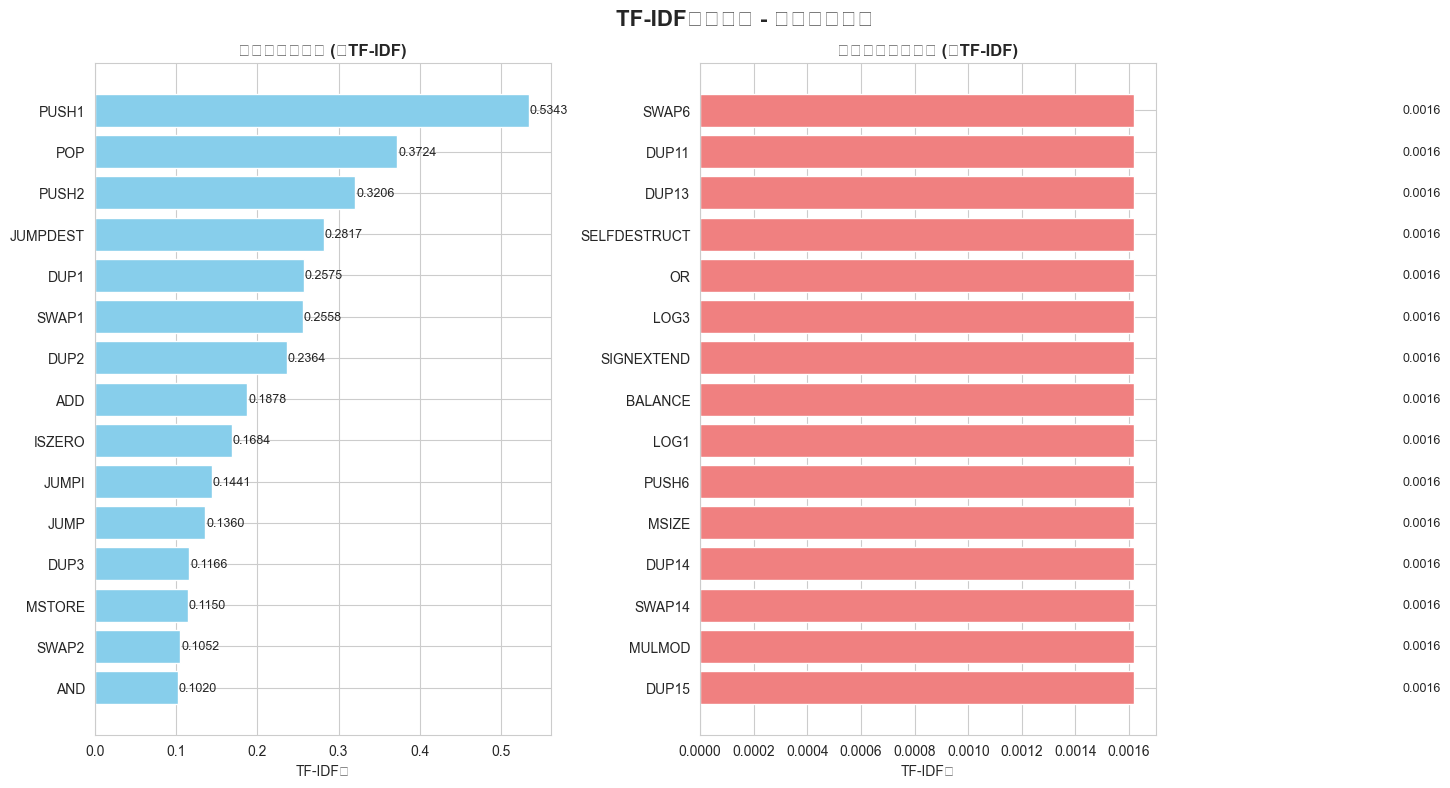

In [152]:
# 提取TF-IDF特征
opcode_features, tfidf_matrix, unique_opcodes = tfidf_opcode_features(ponzi_concat_opcode_sequence)

# 可视化结果
top_ops, bottom_ops = visualize_tfidf_features(opcode_features)

# 为序列中的每个节点创建特征矩阵
opcodes_list = ponzi_concat_opcode_sequence.split()
node_feature_matrix = create_node_feature_matrix(opcodes_list, opcode_features)

### 迁移到所有的合约账户的，构建一个字典存储每个合约账户的类别分布情况

In [153]:
opcode_dict = {}
for address, opcode, label in ponzi_concat[['address','opcode','label']].values:
    categorized1, opcode_freq1 = classify_and_visualize_opcodes(opcode, opcode_categories)
    opcode_features, tfidf_matrix, unique_opcodes = tfidf_opcode_features(opcode)
    opcode_dict[address] = {
        'address': address,
        'opcode': opcode,
        'label': label,
        'category': categorized1,
        'frequency': opcode_freq1,
        'features': opcode_features,
        'tfidf_matrix': tfidf_matrix,
        'unique_opcodes': unique_opcodes
    }

In [154]:
opcode_dict['0x6e38a457c722c6011b2dfa06d49240e797844d66']

{'address': '0x6e38a457c722c6011b2dfa06d49240e797844d66',
 'opcode': 'PUSH1 PUSH1 MSTORE PUSH1 CALLDATALOAD PUSH29 SWAP1 DIV DUP1 PUSH4 EQ PUSH2 JUMPI DUP1 PUSH4 EQ PUSH2 JUMPI DUP1 PUSH4 EQ PUSH2 JUMPI PUSH2 JUMP JUMPDEST STOP JUMPDEST PUSH2 PUSH1 POP PUSH2 JUMP JUMPDEST PUSH1 MLOAD DUP1 DUP3 DUP2 MSTORE PUSH1 ADD SWAP2 POP POP PUSH1 MLOAD DUP1 SWAP2 SUB SWAP1 RETURN JUMPDEST PUSH2 PUSH1 DUP1 CALLDATALOAD SWAP1 PUSH1 ADD POP PUSH2 JUMP JUMPDEST PUSH1 MLOAD DUP1 DUP5 PUSH20 AND DUP2 MSTORE PUSH1 ADD DUP1 PUSH1 ADD DUP4 DUP2 MSTORE PUSH1 ADD DUP3 DUP2 SUB DUP3 MSTORE DUP5 DUP2 DUP2 SLOAD DUP2 MSTORE PUSH1 ADD SWAP2 POP DUP1 SLOAD DUP1 ISZERO PUSH2 JUMPI DUP3 ADD SWAP2 SWAP1 PUSH1 MSTORE PUSH1 PUSH1 SHA3 SWAP1 JUMPDEST DUP2 SLOAD DUP2 MSTORE SWAP1 PUSH1 ADD SWAP1 PUSH1 ADD DUP1 DUP4 GT PUSH2 JUMPI DUP3 SWAP1 SUB PUSH1 AND DUP3 ADD SWAP2 JUMPDEST POP POP SWAP5 POP POP POP POP POP PUSH1 MLOAD DUP1 SWAP2 SUB SWAP1 RETURN JUMPDEST PUSH2 PUSH1 DUP1 CALLDATALOAD SWAP1 PUSH1 ADD SWAP1 PUSH1 ADD

In [155]:
ponzi_concat[['address','opcode','label']]

,address,opcode,label
0,0x6e38a457c722c6011b2dfa06d49240e797844d66,PUSH1 PUSH1 MSTORE PUSH1 CALLDATALOAD PUSH29 S...,0
1,0x109c4f2ccc82c4d77bde15f306707320294aea3f,PUSH1 PUSH1 MSTORE CALLDATASIZE ISZERO PUSH2 J...,1
2,0x793ae8c1b1a160bfc07bfb0d04f85eab1a71f4f2,PUSH1 PUSH1 MSTORE PUSH1 CALLDATALOAD PUSH29 S...,0
3,0x5fe5b7546d1628f7348b023a0393de1fc825a4fd,PUSH1 PUSH1 MSTORE CALLDATASIZE ISZERO PUSH2 J...,0
4,0xd79b4c6791784184e2755b2fc1659eaab0f80456,PUSH1 PUSH1 MSTORE CALLDATASIZE ISZERO PUSH2 J...,0
...,...,...,...
6493,0xdddc5b65208287168bb640e8b303eaaafe2ea95f,PUSH1 PUSH1 MSTORE PUSH2 CALLVALUE LT PUSH2 JU...,1
6494,0x69d1ef860246fa242041bf1d784e8cb43e2a9b07,PUSH1 PUSH1 MSTORE PUSH1 CALLDATASIZE LT PUSH2...,1
6495,0x59edd9c93576bb0b09996c7da47a62e917c6caa9,PUSH1 PUSH1 MSTORE PUSH1 CALLDATASIZE LT PUSH2...,1
6496,0x5a8f9a2533ba8d11e743455ab338391d56f5ee6b,PUSH1 PUSH1 MSTORE PUSH1 CALLDATASIZE LT PUSH2...,1


In [156]:
ponzi_concat1 = ponzi_concat[ponzi_concat['address']=='0x6e38a457c722c6011b2dfa06d49240e797844d66']

In [160]:
a_list = ponzi_concat1['opcode'].values[0].split()

In [128]:
opcode_dict['0x6e38a457c722c6011b2dfa06d49240e797844d66']['opcode']

'PUSH1 PUSH1 MSTORE PUSH1 CALLDATALOAD PUSH29 SWAP1 DIV DUP1 PUSH4 EQ PUSH2 JUMPI DUP1 PUSH4 EQ PUSH2 JUMPI DUP1 PUSH4 EQ PUSH2 JUMPI PUSH2 JUMP JUMPDEST STOP JUMPDEST PUSH2 PUSH1 POP PUSH2 JUMP JUMPDEST PUSH1 MLOAD DUP1 DUP3 DUP2 MSTORE PUSH1 ADD SWAP2 POP POP PUSH1 MLOAD DUP1 SWAP2 SUB SWAP1 RETURN JUMPDEST PUSH2 PUSH1 DUP1 CALLDATALOAD SWAP1 PUSH1 ADD POP PUSH2 JUMP JUMPDEST PUSH1 MLOAD DUP1 DUP5 PUSH20 AND DUP2 MSTORE PUSH1 ADD DUP1 PUSH1 ADD DUP4 DUP2 MSTORE PUSH1 ADD DUP3 DUP2 SUB DUP3 MSTORE DUP5 DUP2 DUP2 SLOAD DUP2 MSTORE PUSH1 ADD SWAP2 POP DUP1 SLOAD DUP1 ISZERO PUSH2 JUMPI DUP3 ADD SWAP2 SWAP1 PUSH1 MSTORE PUSH1 PUSH1 SHA3 SWAP1 JUMPDEST DUP2 SLOAD DUP2 MSTORE SWAP1 PUSH1 ADD SWAP1 PUSH1 ADD DUP1 DUP4 GT PUSH2 JUMPI DUP3 SWAP1 SUB PUSH1 AND DUP3 ADD SWAP2 JUMPDEST POP POP SWAP5 POP POP POP POP POP PUSH1 MLOAD DUP1 SWAP2 SUB SWAP1 RETURN JUMPDEST PUSH2 PUSH1 DUP1 CALLDATALOAD SWAP1 PUSH1 ADD SWAP1 PUSH1 ADD DUP1 CALLDATALOAD SWAP1 PUSH1 ADD SWAP2 SWAP2 SWAP1 DUP1 DUP1 PUSH1 

In [163]:
# 构建每个操作码的表示

representations = [opcode_dict['0x6e38a457c722c6011b2dfa06d49240e797844d66']['features'][opcode] for opcode in opcode_dict['0x6e38a457c722c6011b2dfa06d49240e797844d66']['opcode'].split()]

In [167]:
# 构建 DataFrame
data = {
    'Position': range(len(opcode_dict['0x6e38a457c722c6011b2dfa06d49240e797844d66']['opcode'].split())),
    'Opcode': [opcode for opcode in opcode_dict['0x6e38a457c722c6011b2dfa06d49240e797844d66']['opcode'].split()],
    'TF-IDF': [opcode_dict['0x6e38a457c722c6011b2dfa06d49240e797844d66']['features'][opcode] for opcode in opcode_dict['0x6e38a457c722c6011b2dfa06d49240e797844d66']['opcode'].split()]
}
df = pd.DataFrame(data)

### 生成了一个有序操作有向图，我们能够为每一个账户生成一个对应有序操作有向图

c1——>c2——>c3——>c4——>c5——>c6——>c7......——>cn

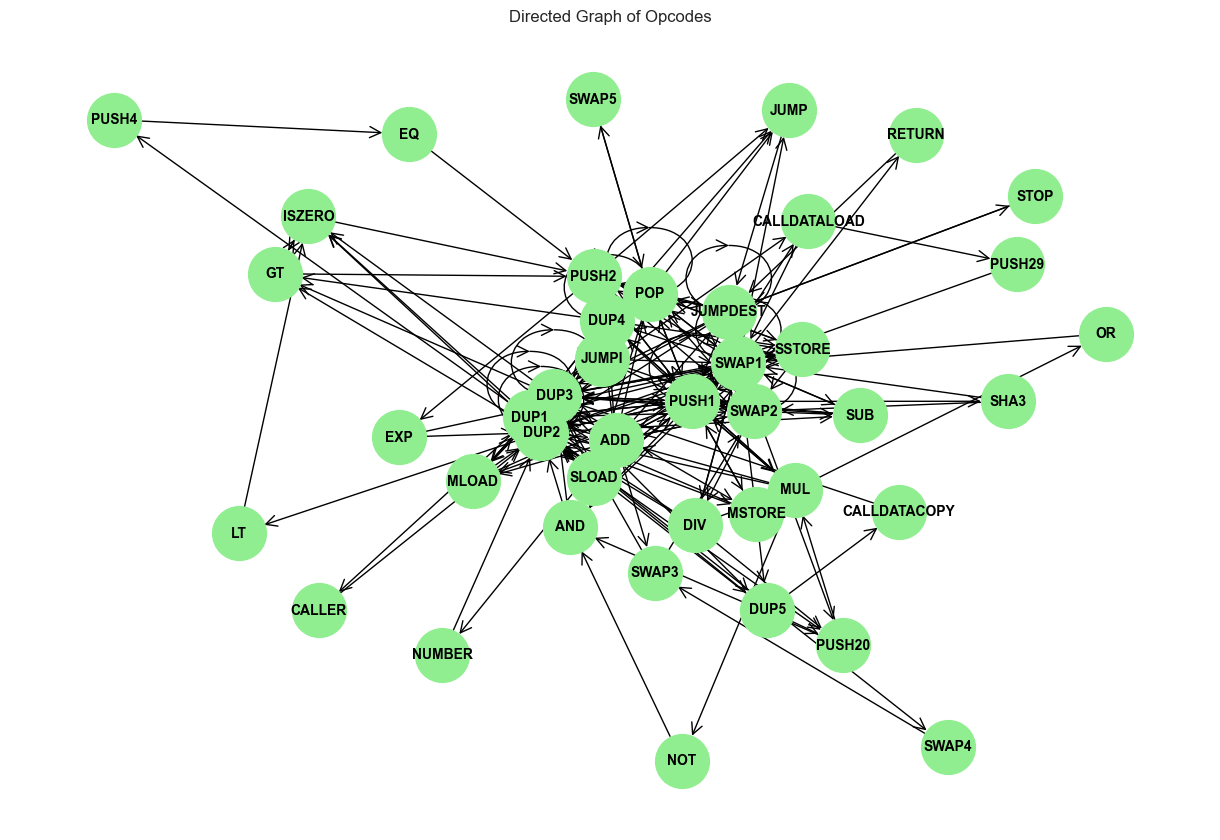

In [182]:
import networkx as nx
import matplotlib.pyplot as plt

# 操作码序列
opcodes = opcode_dict['0x6e38a457c722c6011b2dfa06d49240e797844d66']['opcode'].split()

# 创建有向图
G = nx.DiGraph()

# 提取唯一节点（不同的操作码）
nodes = list(set(opcodes))

# 添加节点
G.add_nodes_from(nodes)

# 构建边（相邻操作码之间的关系）
for i in range(len(opcodes) - 1):
    source = opcodes[i]
    target = opcodes[i + 1]
    G.add_edge(source, target)

# 绘制有向图
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G)  # 使用spring布局
nx.draw(G, pos, with_labels=True, node_color='lightgreen', node_size=1500, 
        arrowstyle='->', arrowsize=20, font_size=10, font_weight='bold')
plt.title("Directed Graph of Opcodes")
plt.axis('off')
plt.show()

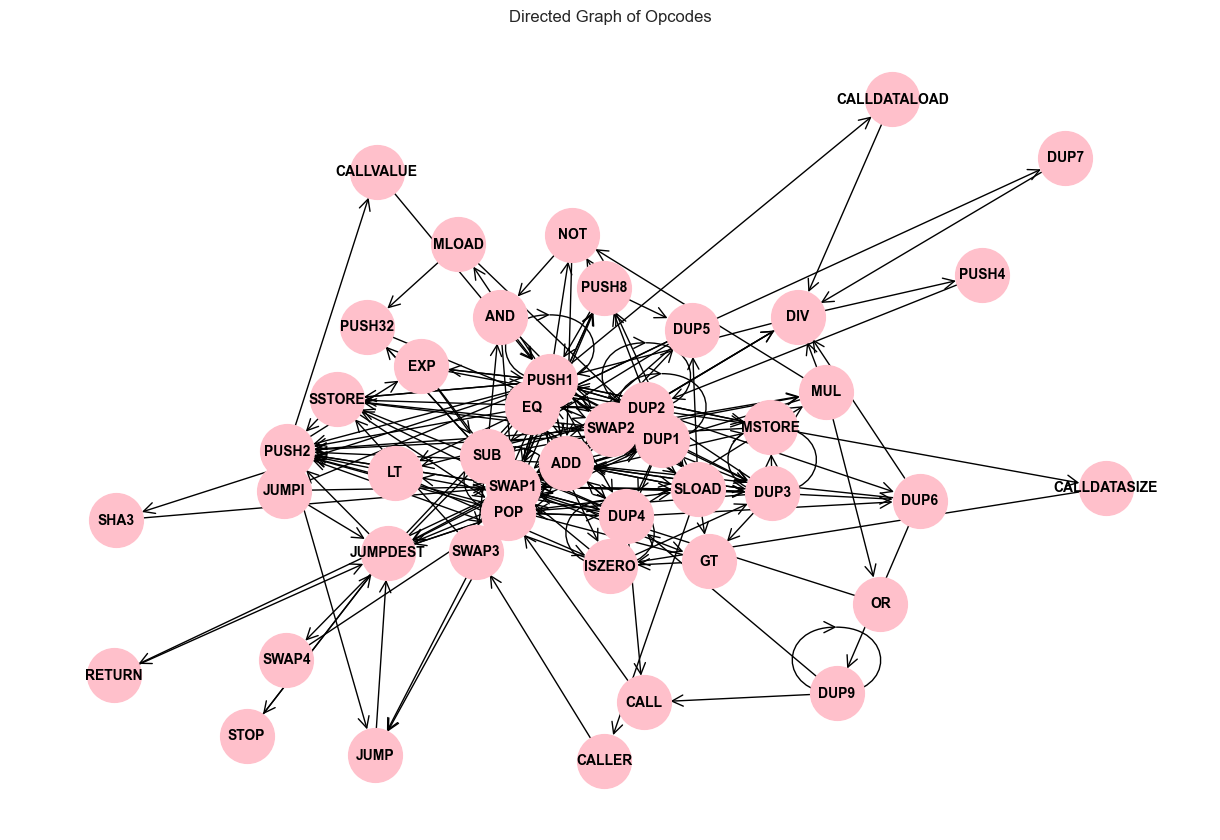

In [180]:
import networkx as nx
import matplotlib.pyplot as plt

# 操作码序列
opcodes = opcode_dict['0x109c4f2ccc82c4d77bde15f306707320294aea3f']['opcode'].split()

# 创建有向图
G = nx.DiGraph()

# 提取唯一节点（不同的操作码）
nodes = list(set(opcodes))

# 添加节点
G.add_nodes_from(nodes)

# 构建边（相邻操作码之间的关系）
for i in range(len(opcodes) - 1):
    source = opcodes[i]
    target = opcodes[i + 1]
    G.add_edge(source, target)

# 绘制有向图
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G)  # 使用spring布局
nx.draw(G, pos, with_labels=True, node_color='pink', node_size=1500, 
        arrowstyle='->', arrowsize=20, font_size=10, font_weight='bold')
plt.title("Directed Graph of Opcodes")
plt.axis('off')
plt.show()